In [1]:
!pip install transformers torchvision pandas scikit-learn pillow tqdm

In [2]:
import os
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!cp "/content/drive/MyDrive/SLP_Project/mvsa_s.zip" /content/
!cp "/content/drive/MyDrive/SLP_Project/mvsa_m.zip" /content/

In [9]:
!unzip -q mvsa_s.zip -d /content/mvsa_s
!unzip -q mvsa_m.zip -d /content/mvsa_m

In [11]:
!ls /content/mvsa_s/MVSA_Single
!ls /content/mvsa_m/MVSA

data  labelResultAll.txt
data  labelResultAll.txt


In [12]:
SINGLE_PATH = "/content/mvsa_s/MVSA_Single"
MULTI_PATH = "/content/mvsa_m/MVSA"

In [25]:
import os

df = df[df['image'].apply(os.path.exists)]

# Fix labels like "positive,positive"
df['label'] = df['label'].apply(lambda x: str(x).split(',')[0])

df = df[df['label'].isin(['positive', 'negative', 'neutral'])]

print("After cleaning:", len(df))

After cleaning: 1500


In [27]:
import pandas as pd
import os

def load_mvsa(base_path):
    label_file = os.path.join(base_path, "labelResultAll.txt")
    data_folder = os.path.join(base_path, "data")

    data = []

    with open(label_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 2:
                continue

            img_id = parts[0]
            label = parts[1]

            img_path = os.path.join(data_folder, f"{img_id}.jpg")
            txt_path = os.path.join(data_folder, f"{img_id}.txt")

            # Read caption
            if os.path.exists(txt_path):
                with open(txt_path, 'r', encoding='utf-8', errors='ignore') as t:
                    text = t.read().strip()
            else:
                text = ""

            data.append([img_path, text, label])

    return pd.DataFrame(data, columns=["image", "text", "label"])

In [28]:
df_single = load_mvsa(SINGLE_PATH)
df_multi = load_mvsa(MULTI_PATH)

df = pd.concat([df_single, df_multi], ignore_index=True)

print("Total samples:", len(df))
df.head()

Total samples: 24471


,image,text,label
0,/content/mvsa_s/MVSA_Single/data/ID.jpg,,"text,image"
1,/content/mvsa_s/MVSA_Single/data/1.jpg,How I feel today #legday #jelly #aching #gym,"neutral,positive"
2,/content/mvsa_s/MVSA_Single/data/2.jpg,grattis min griskulting!!!???? va bara tvungen...,"neutral,positive"
3,/content/mvsa_s/MVSA_Single/data/3.jpg,RT @polynminion: The moment I found my favouri...,"neutral,positive"
4,/content/mvsa_s/MVSA_Single/data/4.jpg,#escort We have a young and energetic team and...,"positive,positive"


In [29]:
import os

# Remove missing images
df = df[df['image'].apply(os.path.exists)]

# Remove empty captions
df = df[df['text'].astype(str).str.strip() != ""]

# Fix labels like "positive,positive"
df['label'] = df['label'].apply(lambda x: str(x).split(',')[0])

# Keep valid labels only
df = df[df['label'].isin(['positive', 'negative', 'neutral'])]

print("After cleaning:", len(df))
df.head()

After cleaning: 24469


,image,text,label
1,/content/mvsa_s/MVSA_Single/data/1.jpg,How I feel today #legday #jelly #aching #gym,neutral
2,/content/mvsa_s/MVSA_Single/data/2.jpg,grattis min griskulting!!!???? va bara tvungen...,neutral
3,/content/mvsa_s/MVSA_Single/data/3.jpg,RT @polynminion: The moment I found my favouri...,neutral
4,/content/mvsa_s/MVSA_Single/data/4.jpg,#escort We have a young and energetic team and...,positive
5,/content/mvsa_s/MVSA_Single/data/5.jpg,"RT @chrisashaffer: Went to SSC today to be a ""...",positive


In [31]:
df = df.sample(1500, random_state=42).reset_index(drop=True)

In [47]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion"
)

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [49]:
from tqdm import tqdm
tqdm.pandas()

def clean_text(text):
    return str(text).lower().strip()

def get_emotion(text):
    try:
        result = emotion_classifier(text[:512])[0]
        if result['score'] < 0.6:
            return "neutral"
        return result['label']
    except:
        return "neutral"

df['clean_text'] = df['text'].apply(clean_text)
df['emotion'] = df['clean_text'].progress_apply(get_emotion)

print(df['emotion'].value_counts())

100%|██████████| 1500/1500 [03:54<00:00,  6.40it/s]

emotion
joy         905
neutral     200
anger       198
sadness      87
fear         54
love         47
surprise      9
Name: count, dtype: int64


In [50]:
from sklearn.preprocessing import LabelEncoder

sent_le = LabelEncoder()
df['sentiment'] = sent_le.fit_transform(df['label'])

emo_le = LabelEncoder()
df['emotion'] = emo_le.fit_transform(df['emotion'])

In [51]:
import torch
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')
bert.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [52]:
from torchvision import models, transforms
from PIL import Image

resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [53]:
def get_text_features(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = bert(**inputs)
    return outputs.last_hidden_state[:,0,:]

In [54]:
def get_image_features(path):
    img = Image.open(path).convert('RGB')
    img = transform(img).unsqueeze(0)

    with torch.no_grad():
        features = resnet(img)

    return features.view(1, -1)

In [55]:
import numpy as np

X, y_sent, y_emo = [], [], []

for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text_feat = get_text_features(row['text'])
        img_feat = get_image_features(row['image'])

        combined = torch.cat((text_feat, img_feat), dim=1)

        X.append(combined.squeeze().numpy())
        y_sent.append(row['sentiment'])
        y_emo.append(row['emotion'])
    except:
        continue

X = np.array(X)
y_sent = np.array(y_sent)
y_emo = np.array(y_emo)

print("Feature shape:", X.shape)

100%|██████████| 1500/1500 [12:52<00:00,  1.94it/s]

Feature shape: (1500, 2816)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_sent_train, y_sent_test, y_emo_train, y_emo_test = train_test_split(
    X, y_sent, y_emo, test_size=0.2, random_state=42
)

In [58]:
import torch.nn as nn

class MultiTaskModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3)
        )
        self.sentiment_head = nn.Linear(512, 3)
        self.emotion_head = nn.Linear(512, len(emo_le.classes_))

    def forward(self, x):
        x = self.shared(x)
        return self.sentiment_head(x), self.emotion_head(x)

In [59]:
model = MultiTaskModel(X.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_sent_t = torch.tensor(y_sent_train)
y_emo_t = torch.tensor(y_emo_train)

for epoch in range(10):
    model.train()
    sent_out, emo_out = model(X_train_t)

    loss = loss_fn(sent_out, y_sent_t) + loss_fn(emo_out, y_emo_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 3.3637
Epoch 2, Loss: 3.1648
Epoch 3, Loss: 3.0487
Epoch 4, Loss: 2.8720
Epoch 5, Loss: 2.7444
Epoch 6, Loss: 2.6343
Epoch 7, Loss: 2.5131
Epoch 8, Loss: 2.4025
Epoch 9, Loss: 2.2990
Epoch 10, Loss: 2.2269


In [60]:
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)
sent_out, emo_out = model(X_test_t)

_, sent_preds = torch.max(sent_out, 1)
_, emo_preds = torch.max(emo_out, 1)

In [61]:
from sklearn.metrics import *

print("SENTIMENT")
print("Accuracy:", accuracy_score(y_sent_test, sent_preds))
print("Precision:", precision_score(y_sent_test, sent_preds, average='weighted'))
print("Recall:", recall_score(y_sent_test, sent_preds, average='weighted'))
print("F1:", f1_score(y_sent_test, sent_preds, average='weighted'))

print(classification_report(y_sent_test, sent_preds))

SENTIMENT
Accuracy: 0.5266666666666666
Precision: 0.5230177360459052
Recall: 0.5266666666666666
F1: 0.5246992303188152
              precision    recall  f1-score   support

           0       0.31      0.28      0.29        40
           1       0.50      0.50      0.50       121
           2       0.61      0.62      0.61       139

    accuracy                           0.53       300
   macro avg       0.47      0.47      0.47       300
weighted avg       0.52      0.53      0.52       300



In [62]:
print("EMOTION")
print("Accuracy:", accuracy_score(y_emo_test, emo_preds))
print("Precision:", precision_score(y_emo_test, emo_preds, average='weighted'))
print("Recall:", recall_score(y_emo_test, emo_preds, average='weighted'))
print("F1:", f1_score(y_emo_test, emo_preds, average='weighted'))

print(classification_report(y_emo_test, emo_preds))

EMOTION
Accuracy: 0.36666666666666664
Precision: 0.5382719082199103
Recall: 0.36666666666666664
F1: 0.4239700671649545
              precision    recall  f1-score   support

           0       0.33      0.29      0.31        42
           1       0.03      0.22      0.05         9
           2       0.78      0.44      0.56       165
           3       0.27      0.35      0.31        17
           4       0.25      0.31      0.28        48
           5       0.12      0.11      0.12        18
           6       0.00      0.00      0.00         1

    accuracy                           0.37       300
   macro avg       0.26      0.25      0.23       300
weighted avg       0.54      0.37      0.42       300



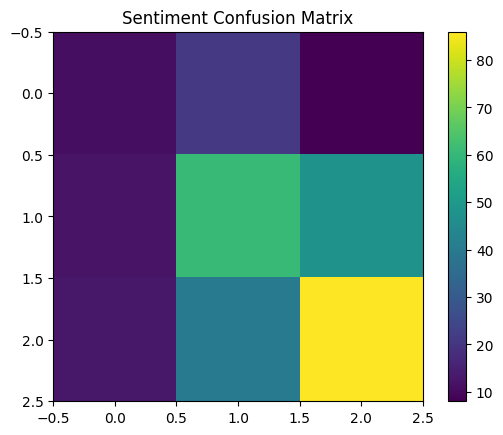

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_sent_test, sent_preds)

plt.imshow(cm)
plt.title("Sentiment Confusion Matrix")
plt.colorbar()
plt.show()

In [64]:
sent_labels = sent_le.inverse_transform(sent_preds.numpy())
emo_labels = emo_le.inverse_transform(emo_preds.numpy())

output = pd.DataFrame({
    "image": df.iloc[:len(sent_preds)]['image'],
    "text": df.iloc[:len(sent_preds)]['text'],
    "predicted_sentiment": sent_labels,
    "predicted_emotion": emo_labels
})

output.to_csv("/content/final_output.csv", index=False)